# PROJECT PCD KELOMPOK 6
- Kevin Foreman Hutahaen (24031554049)
- Kartika Nur Savira (24031554049)
- Arimby Deby Setyoningrum (24031554049)

# Deteksi Fraktur Tulang pada Citra X-Ray Menggunakan Metode Convolutional Neural Network (CNN)

Dataset : https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project/data

# LOAD DATA

In [ ]:
from pathlib import Path
import os
import subprocess
import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml
from collections import Counter


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

In [ ]:
!pip install -q kaggle kagglehub pyyaml

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/bone-fracture-detection-computer-vision-project")
print("Path to dataset files:", path)

100%|██████████| 84.1M/84.1M [00:00<00:00, 98.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pkdarabi/bone-fracture-detection-computer-vision-project/versions/2


## Cek Struktur Dataset

In [ ]:
# Tampilkan struktur folder (2 level)
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 2:
        indent = '  ' * depth
        print(f'{indent}{os.path.basename(root)}/')
        if depth == 2:
            subindent = '  ' * (depth + 1)
            print(f'{subindent}({len(files)} files)')

2/
  BoneFractureYolo8/
    test/
      (0 files)
    valid/
      (0 files)
    train/
      (0 files)
  bone fracture detection.v4-v4.yolov8/
    test/
      (0 files)
    valid/
      (0 files)
    train/
      (0 files)


## Pilih Sub-Dataset yang Digunakan

Dataset ini memiliki dua sub-folder:
- `BoneFractureYolo8/` — dataset YOLO dengan class ID numerik
- `bone fracture detection.v4-v4.yolov8/` — dataset Roboflow dengan 6 kelas bernama

Kita gunakan **`BoneFractureYolo8/`** dan baca nama kelas dari file `data.yaml`.

In [ ]:
dataset_path = Path(path) / "BoneFractureYolo8"

# Baca nama kelas dari data.yaml
yaml_path = dataset_path / "data.yaml"

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml.get('names', [])
print("Jumlah kelas:", len(class_names))
print("Nama kelas:")
for i, name in enumerate(class_names):
    print(f"  ID {i}: {name}")

Jumlah kelas: 7
Nama kelas:
  ID 0: elbow positive
  ID 1: fingers positive
  ID 2: forearm fracture
  ID 3: humerus fracture
  ID 4: humerus
  ID 5: shoulder fracture
  ID 6: wrist positive


# EDA — Exploratory Data Analysis

## 1. Distribusi Data
### 1.1 Total Gambar per Split

Train :  3631 gambar
Valid :   348 gambar
Test  :   169 gambar
Total :  4148 gambar


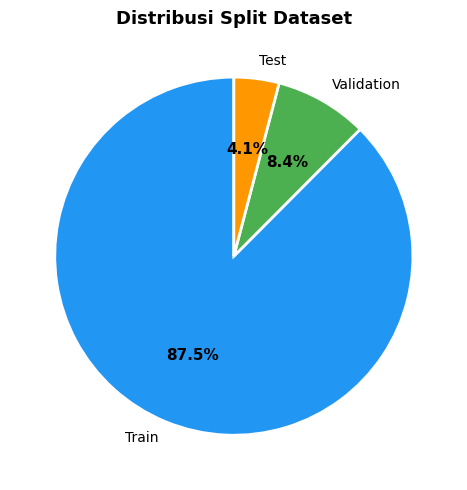

In [ ]:
# Ambil hanya gambar dari BoneFractureYolo8
image_files_train = list((dataset_path / 'train' / 'images').glob('*.jpg'))
image_files_valid = list((dataset_path / 'valid' / 'images').glob('*.jpg'))
image_files_test  = list((dataset_path / 'test'  / 'images').glob('*.jpg'))

image_files_all = image_files_train + image_files_valid + image_files_test

print(f"Train : {len(image_files_train):>5} gambar")
print(f"Valid : {len(image_files_valid):>5} gambar")
print(f"Test  : {len(image_files_test):>5} gambar")
print(f"Total : {len(image_files_all):>5} gambar")

# Visualisasi pie chart
labels = ['Train', 'Validation', 'Test']
sizes  = [len(image_files_train), len(image_files_valid), len(image_files_test)]
colors = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(6, 5))
wedges, texts, autotexts = plt.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
plt.title('Distribusi Split Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.2 Distribusi Kelas (dengan Nama Kelas)

In [ ]:
# Hitung distribusi kelas dari label train saja
label_files_train = list((dataset_path / 'train' / 'labels').glob('*.txt'))

class_counts = Counter()

for label_file in label_files_train:
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            # Filter: hanya baris yang class ID-nya berupa angka
            if len(parts) >= 5 and parts[0].isdigit():
                class_id = int(parts[0])
                class_counts[class_id] += 1

print("Distribusi kelas (train set):")
for cls_id, count in sorted(class_counts.items()):
    name = class_names[cls_id] if cls_id < len(class_names) else f'Unknown ({cls_id})'
    print(f"  [{cls_id}] {name:<25}: {count:>5} bounding box")

Distribusi kelas (train set):
  [0] elbow positive           :   339 bounding box
  [1] fingers positive         :   531 bounding box
  [2] forearm fracture         :   316 bounding box
  [3] humerus fracture         :     3 bounding box
  [4] humerus                  :   311 bounding box
  [5] shoulder fracture        :   360 bounding box
  [6] wrist positive           :   228 bounding box


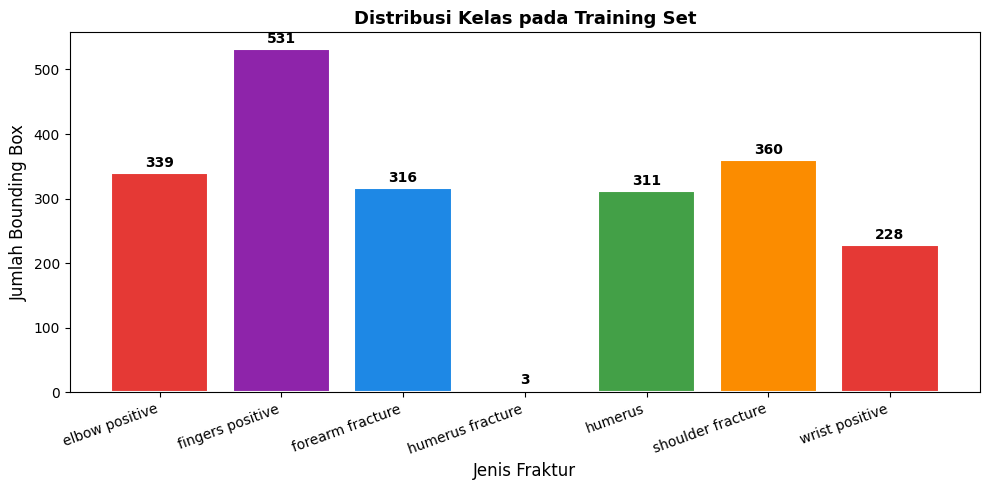

In [ ]:
# Visualisasi bar chart distribusi kelas dengan nama
sorted_items = sorted(class_counts.items())
ids    = [str(i) for i, _ in sorted_items]
counts = [c for _, c in sorted_items]
names  = [class_names[i] if i < len(class_names) else str(i) for i, _ in sorted_items]

colors_bar = ['#E53935', '#8E24AA', '#1E88E5', '#00ACC1', '#43A047', '#FB8C00']

plt.figure(figsize=(10, 5))
bars = plt.bar(names, counts, color=colors_bar[:len(names)], edgecolor='white', linewidth=1.5)

# Tambahkan label jumlah di atas bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xlabel('Jenis Fraktur', fontsize=12)
plt.ylabel('Jumlah Bounding Box', fontsize=12)
plt.title('Distribusi Kelas pada Training Set', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

 elbow positive       0.82      0.94      0.88        50

 fingers positive       0.69      0.94      0.80        54

 forearm fracture       0.80      0.72      0.76        39

 humerus fracture       0.87      0.87      0.87        46
          
humerus       0.88      0.92      0.90        50

shoulder fracture

### 1.3 Cek Data Imbalance

In [ ]:
total_bbox = sum(class_counts.values())
max_count  = max(class_counts.values())
min_count  = min(class_counts.values())
max_class  = class_names[max(class_counts, key=class_counts.get)]
min_class  = class_names[min(class_counts, key=class_counts.get)]

print("=== Analisis Class Imbalance ===")
print(f"Total bounding box : {total_bbox}")
print(f"Kelas terbanyak    : {max_class} ({max_count} bbox)")
print(f"Kelas tersedikit   : {min_class} ({min_count} bbox)")
print(f"Rasio imbalance    : {max_count/min_count:.1f}:1")
print()
print("Persentase tiap kelas:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names[cls_id]
    pct  = count / total_bbox * 100
    bar  = '█' * int(pct / 2)
    print(f"  {name:<25}: {pct:5.1f}% {bar}")

=== Analisis Class Imbalance ===
Total bounding box : 2088
Kelas terbanyak    : fingers positive (531 bbox)
Kelas tersedikit   : humerus fracture (3 bbox)
Rasio imbalance    : 177.0:1

Persentase tiap kelas:
  elbow positive           :  16.2% ████████
  fingers positive         :  25.4% ████████████
  forearm fracture         :  15.1% ███████
  humerus fracture         :   0.1% 
  humerus                  :  14.9% ███████
  shoulder fracture        :  17.2% ████████
  wrist positive           :  10.9% █████


### 1.4 Visualisasi Sample Gambar per Kelas

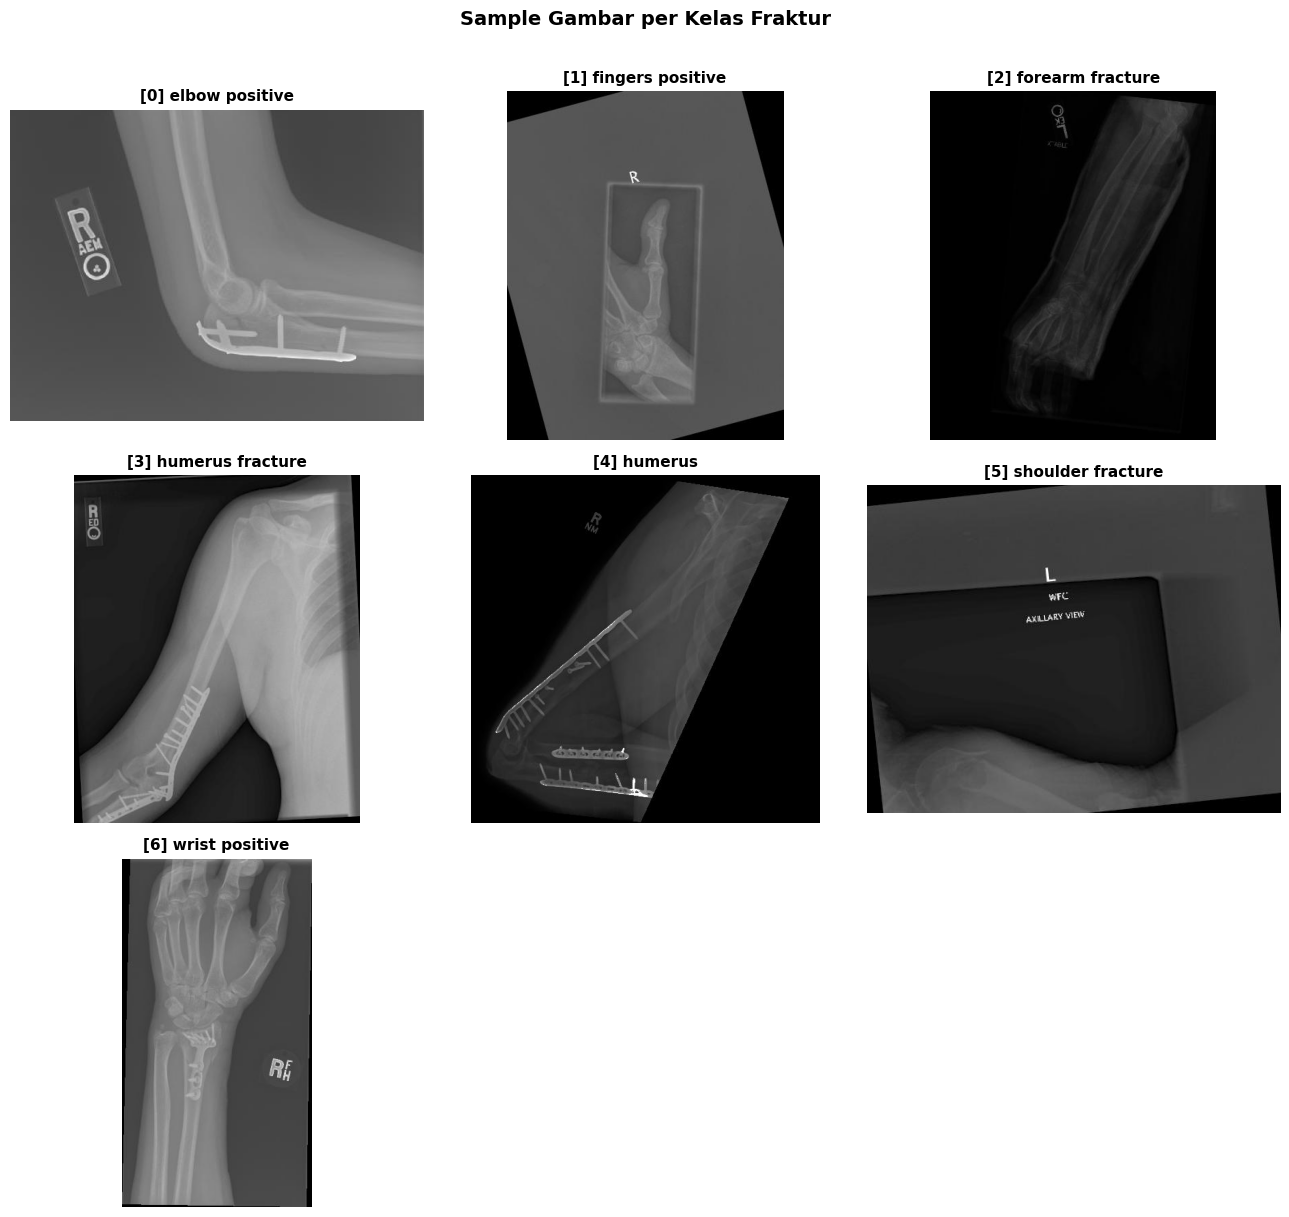

In [ ]:
class_to_images = {i: [] for i in range(len(class_names))}

for label_file in label_files_train:
    img_file = dataset_path / 'train' / 'images' / (label_file.stem + '.jpg')
    if not img_file.exists():
        continue
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5 and parts[0].isdigit():
                cls_id = int(parts[0])
                if img_file not in class_to_images[cls_id]:
                    class_to_images[cls_id].append(img_file)

num_classes = len(class_names)
n_cols = 3
n_rows = (num_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
axes = axes.flatten()

for i in range(num_classes):
    ax = axes[i]
    cls_id = i
    name = class_names[cls_id]

    if class_to_images[cls_id]:
        img_path = class_to_images[cls_id][0]
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f'[{cls_id}] {name}', fontsize=11, fontweight='bold', pad=6)
    else:
        ax.text(0.5, 0.5, 'No sample', ha='center', va='center', fontsize=12)
    ax.axis('off')


for j in range(num_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Gambar per Kelas Fraktur', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.5 Analisis Kontras (Histogram Intensitas)

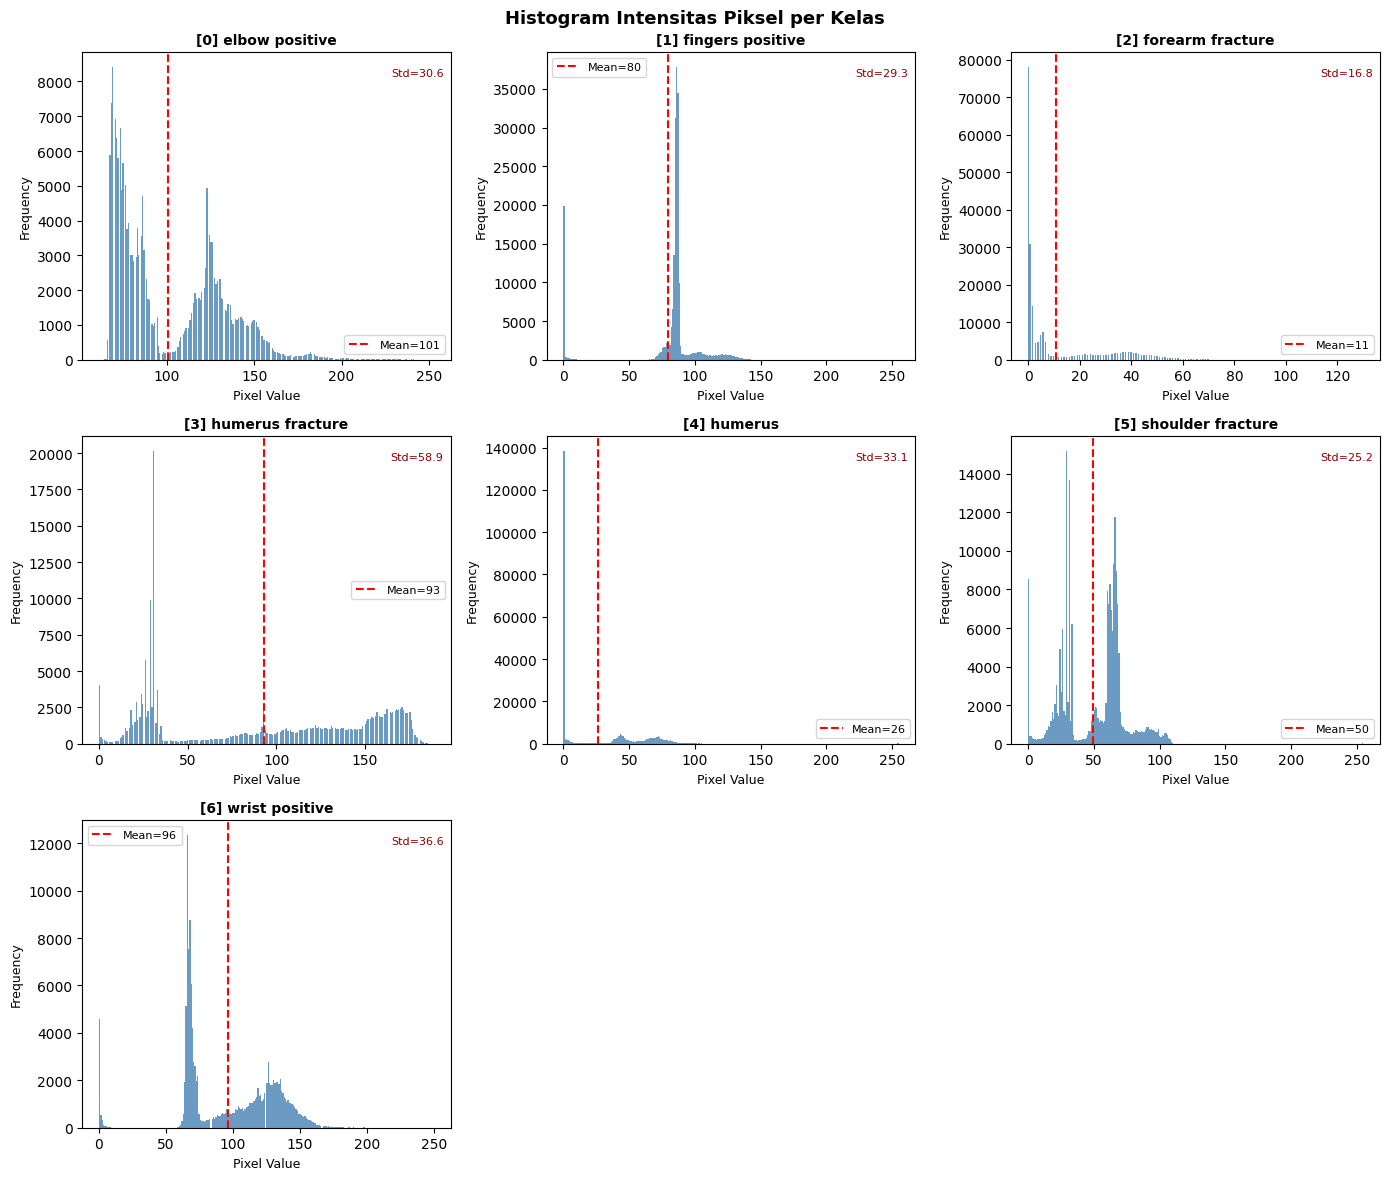

Kesimpulan: histogram sempit -> kontras rendah -> CLAHE direkomendasikan


In [ ]:
# Ambil 1 sampel per kelas lalu tampilkan histogram intensitasnya
num_classes = len(class_names)
n_cols = 3
n_rows = (num_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, name in enumerate(class_names):
    ax = axes[i]
    cls_id = i

    if class_to_images[cls_id]:
        img = cv2.imread(str(class_to_images[cls_id][0]))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mean_val = gray.mean()
        std_val  = gray.std()
        ax.hist(gray.ravel(), bins=256, color='steelblue', alpha=0.8)
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.0f}')
        ax.set_title(f'[{cls_id}] {name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Pixel Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(fontsize=8)
        ax.text(0.98, 0.95, f'Std={std_val:.1f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='darkred')
    else:
        ax.text(0.5, 0.5, 'No sample', ha='center', va='center')

for j in range(num_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('Histogram Intensitas Piksel per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Kesimpulan: histogram sempit -> kontras rendah -> CLAHE direkomendasikan")

### 1.6 Cek Resolusi Gambar

5 Resolusi paling umum (train set):
  420x512 px : 518 gambar
  406x512 px : 443 gambar
  512x406 px : 255 gambar
  512x512 px : 129 gambar
  512x420 px : 117 gambar

Width  — min: 111, max: 2048, rata-rata: 412
Height — min: 134, max: 2048, rata-rata: 486


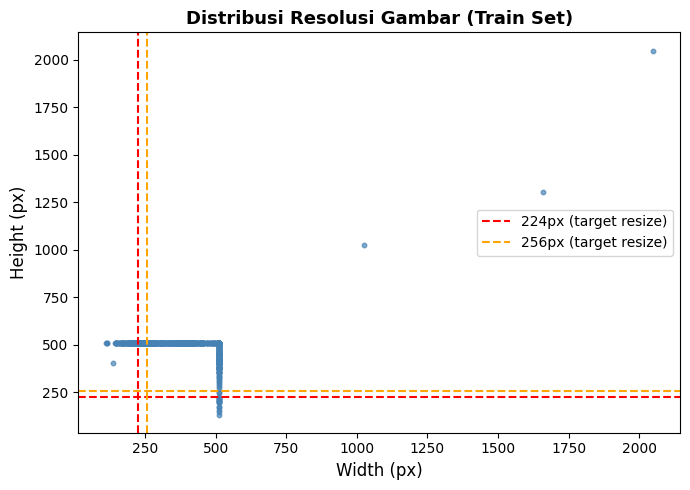

In [ ]:
resolutions = []

for img_path in image_files_train:
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        resolutions.append((w, h))

resolution_counts = Counter(resolutions)

print("5 Resolusi paling umum (train set):")
for res, count in resolution_counts.most_common(5):
    print(f"  {res[0]}x{res[1]} px : {count} gambar")

widths  = [w for w, h in resolutions]
heights = [h for w, h in resolutions]

print(f"\nWidth  — min: {min(widths)}, max: {max(widths)}, rata-rata: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, rata-rata: {np.mean(heights):.0f}")

# Scatter plot resolusi
plt.figure(figsize=(7, 5))
plt.scatter(widths, heights, alpha=0.3, s=10, color='steelblue')
plt.axvline(224, color='red',   linestyle='--', linewidth=1.5, label='224px (target resize)')
plt.axhline(224, color='red',   linestyle='--', linewidth=1.5)
plt.axvline(256, color='orange',linestyle='--', linewidth=1.5, label='256px (target resize)')
plt.axhline(256, color='orange',linestyle='--', linewidth=1.5)
plt.xlabel('Width (px)', fontsize=12)
plt.ylabel('Height (px)', fontsize=12)
plt.title('Distribusi Resolusi Gambar (Train Set)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

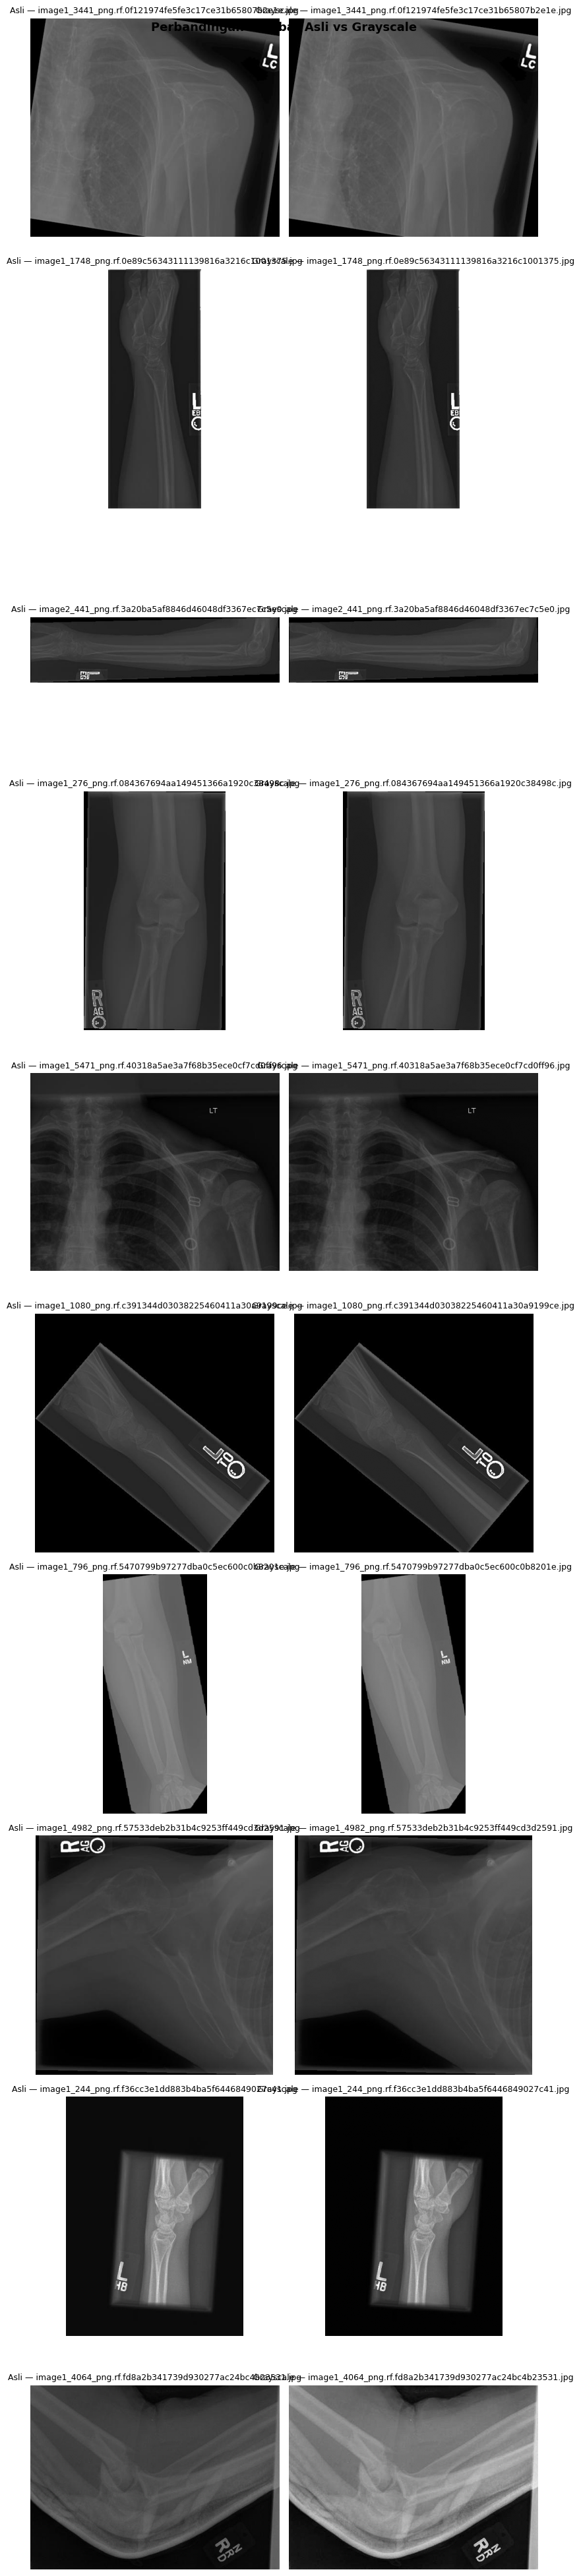

Shape asli  : (379, 512, 3)
Shape gray  : (379, 512)


In [ ]:
image_files_train = list((dataset_path / 'train' / 'images').glob('*.jpg'))

# Tampilkan 10 gambar pertama (bisa diganti jumlahnya)
n_tampil = 10

fig, axes = plt.subplots(n_tampil, 2, figsize=(8, 4 * n_tampil))

for i in range(n_tampil):
    img_bgr = cv2.imread(str(image_files_train[i]))
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Kolom kiri: gambar asli
    axes[i, 0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Asli — {image_files_train[i].name}", fontsize=9)
    axes[i, 0].axis("off")

    # Kolom kanan: grayscale
    axes[i, 1].imshow(gray, cmap="gray")
    axes[i, 1].set_title(f"Grayscale — {image_files_train[i].name}", fontsize=9)
    axes[i, 1].axis("off")

plt.suptitle("Perbandingan Gambar Asli vs Grayscale", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Shape asli  : {img_bgr.shape}")
print(f"Shape gray  : {gray.shape}")

In [ ]:
from collections import Counter

data_dict = {}
for label_file in label_files_train:
    img_file = dataset_path / 'train' / 'images' / (label_file.stem + '.jpg')
    if not img_file.exists():
        continue
    labels_in_image = []
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5 and parts[0].isdigit():
                labels_in_image.append(int(parts[0]))
    if labels_in_image:
        most_common_label = Counter(labels_in_image).most_common(1)[0][0]
        data_dict[str(img_file)] = most_common_label

data = list(data_dict.items())

In [ ]:
import pandas as pd

df = pd.DataFrame(data, columns=["image_path", "label"])

print(df.head())
print("Total data:", len(df))

                                          image_path  label
0  /root/.cache/kagglehub/datasets/pkdarabi/bone-...      4
1  /root/.cache/kagglehub/datasets/pkdarabi/bone-...      1
2  /root/.cache/kagglehub/datasets/pkdarabi/bone-...      2
3  /root/.cache/kagglehub/datasets/pkdarabi/bone-...      2
4  /root/.cache/kagglehub/datasets/pkdarabi/bone-...      1
Total data: 1804


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1262
Val  : 271
Test : 271


In [ ]:
print(train_df["label"].value_counts())
print(val_df["label"].value_counts())
print(test_df["label"].value_counts())

label
1    321
4    212
0    211
5    210
2    201
6    107
Name: count, dtype: int64
label
1    58
5    55
0    45
2    43
4    41
6    29
Name: count, dtype: int64
label
1    54
5    50
0    50
4    46
2    39
6    32
Name: count, dtype: int64


In [ ]:
df = df[df["label"] != 3]

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

# Pre-Processing

## Skenario A

Resize

In [ ]:
def resize_image(img, size=224):
    h, w = img.shape[:2]

    # Hitung scale berdasarkan sisi terpanjang
    scale = size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Resize proporsional dulu
    resized = cv2.resize(img, (new_w, new_h))

    # Buat canvas hitam ukuran size x size
    if len(img.shape) == 3:
        canvas = np.zeros((size, size, img.shape[2]), dtype=resized.dtype)
    else:
        canvas = np.zeros((size, size), dtype=resized.dtype)

    # Tempelkan gambar di tengah canvas (center padding)
    top  = (size - new_h) // 2
    left = (size - new_w) // 2

    canvas[top:top+new_h, left:left+new_w] = resized
    resize = canvas

    return resize

Grayscale

In [ ]:
def convert_grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

Normalize

In [ ]:
def normalize_image(img):
    normalized = img.astype(np.float32) / 255.0
    return normalized

Convert Grayscale to 3 Chanel

In [ ]:
def convert_to_3channel(img):
    img_3ch = np.stack([img] * 3, axis=-1)
    return img_3ch

In [ ]:
def Baseline_A(img_path):

    img = cv2.imread(str(img_path))

    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")

    resized = resize_image(img)
    gray = convert_grayscale(resized)
    normalized = normalize_image(gray)
    final_img = convert_to_3channel(normalized)

    return final_img

Train

In [ ]:
X_train_A = []
y_train_A = []

for _, row in train_df.iterrows():

    img = Baseline_A(row["image_path"])

    if img is not None:
        X_train_A.append(img)
        y_train_A.append(row["label"])

X_train_A = np.array(X_train_A, dtype=np.float32)
y_train_A = np.array(y_train_A, dtype=np.int32)

print(X_train_A.shape, y_train_A.shape)

(1262, 224, 224, 3) (1262,)


Validasi

In [ ]:
X_val_A = []
y_val_A = []

for _, row in val_df.iterrows():

    img = Baseline_A(row["image_path"])

    if img is not None:
        X_val_A.append(img)
        y_val_A.append(row["label"])

X_val_A = np.array(X_val_A, dtype=np.float32)
y_val_A = np.array(y_val_A, dtype=np.int32)

print(X_val_A.shape, y_val_A.shape)

(271, 224, 224, 3) (271,)


Testing

In [ ]:
X_test_A = []
y_test_A = []

for _, row in test_df.iterrows():

    img = Baseline_A(row["image_path"])

    if img is not None:
        X_test_A.append(img)
        y_test_A.append(row["label"])

X_test_A = np.array(X_test_A, dtype=np.float32)
y_test_A = np.array(y_test_A, dtype=np.int32)

print(X_test_A.shape, y_test_A.shape)

(271, 224, 224, 3) (271,)


### Augmentasi

In [ ]:
train_datagen_A = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

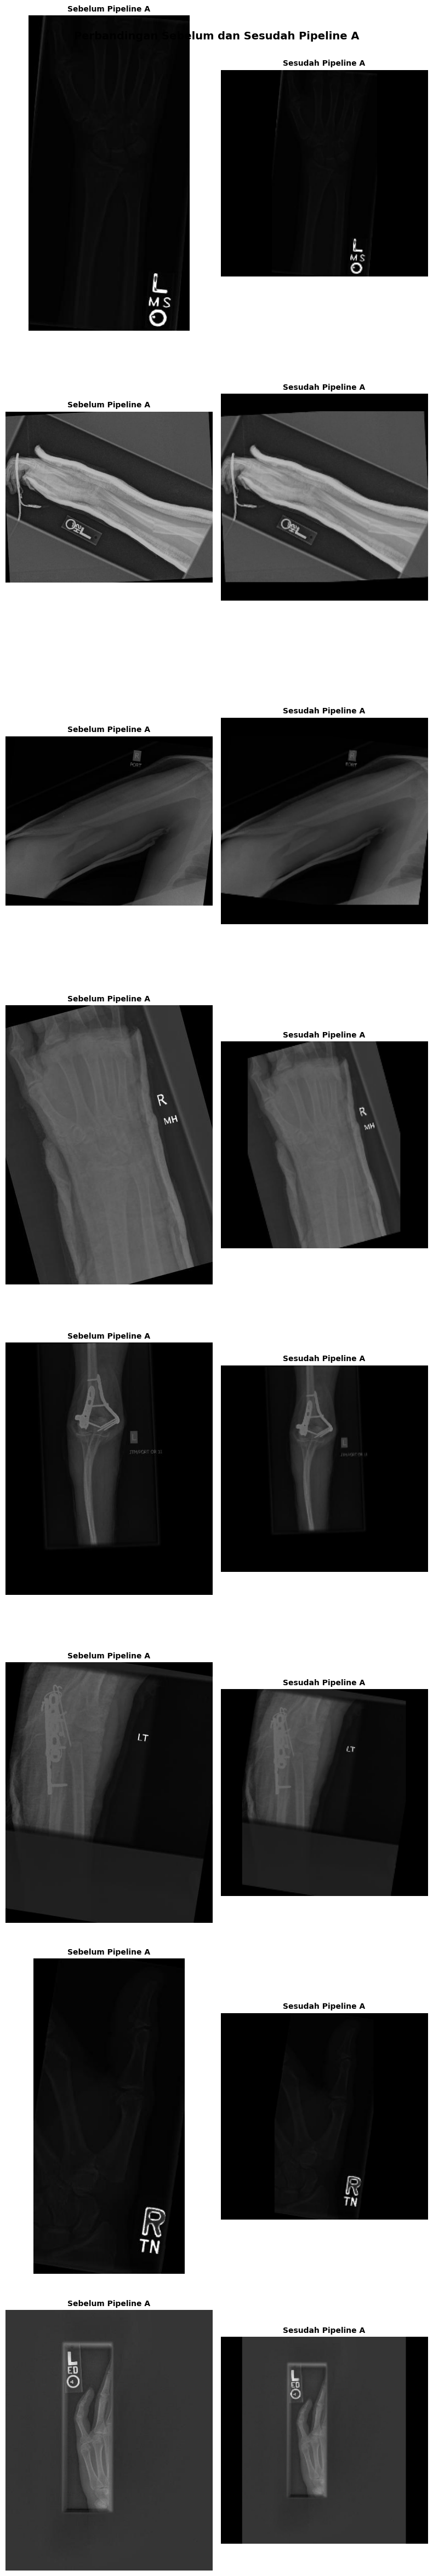

In [ ]:
n_tampil =8

fig, axes = plt.subplots(n_tampil, 2, figsize=(8, 6 * n_tampil))

for i in range(n_tampil):

    img_path = train_df.iloc[i]["image_path"]

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    processed = Baseline_A(img_path)

    processed_show = (processed * 255).astype(np.uint8)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title("Sebelum Pipeline A", fontsize=10, fontweight='bold')
    axes[i, 0].set_aspect('equal')
    axes[i, 0].axis("off")

    axes[i, 1].imshow(processed_show)
    axes[i, 1].set_title("Sesudah Pipeline A", fontsize=10, fontweight='bold')
    axes[i, 1].set_aspect('equal')
    axes[i, 1].axis("off")

plt.suptitle(
    "Perbandingan Sebelum dan Sesudah Pipeline A",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Model Skenario A

Model

In [ ]:
base_model_A = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet')
base_model_A.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


build model

In [ ]:
model_A = models.Sequential([
    base_model_A,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

Classifier

In [ ]:
base_model_A = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet")
base_model_A.trainable = False

compile

In [ ]:
history_A = model_A.fit(
    train_datagen_A.flow(
        X_train_A,
        y_train_A,
        batch_size=32
    ),
    validation_data=(X_val_A, y_val_A),
    epochs=10)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.4485 - loss: 1.4652 - val_accuracy: 0.6605 - val_loss: 0.9628
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6078 - loss: 1.0126 - val_accuracy: 0.7638 - val_loss: 0.7544
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.6870 - loss: 0.8266 - val_accuracy: 0.7675 - val_loss: 0.6710
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7290 - loss: 0.7491 - val_accuracy: 0.7934 - val_loss: 0.6176
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7464 - loss: 0.7240 - val_accuracy: 0.8007 - val_loss: 0.5942
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.7607 - loss: 0.6571 - val_accuracy: 0.8303 - val_loss: 0.5408
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.7734 - loss: 0.6318 - val_accuracy: 0.8266 - val_loss: 0.5431
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7876 - loss: 0.6097 - val_accuracy: 0.8339 - val_los

Evaluasi

In [ ]:
test_loss_A, test_acc_A = model_A.evaluate(X_test_A, y_test_A)

print("Test Accuracy :", test_acc_A)
print("Test Loss     :", test_loss_A)

9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8303 - loss: 0.4879
Test Accuracy : 0.830258309841156
Test Loss     : 0.4878794550895691


Prediksi Model

In [ ]:
y_pred_prob_A = model_A.predict(X_test_A)

y_pred_A = np.argmax(y_pred_prob_A, axis=1)

print(y_pred_A[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step
[1 5 5 1 1 1 2 4 1 1]


Classification Report

In [ ]:
from sklearn.metrics import classification_report
y_pred_prob_A = model_A.predict(X_test_A)
y_pred_A = np.argmax(y_pred_prob_A, axis=1)
print(classification_report(
    y_test_A,
    y_pred_A,
    labels=np.unique(y_test_A),
    target_names=[class_names[i] for i in np.unique(y_test_A)]
))

9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
                   precision    recall  f1-score   support

   elbow positive       0.87      0.96      0.91        50
 fingers positive       0.79      0.89      0.83        54
 forearm fracture       0.76      0.79      0.78        39
          humerus       0.85      0.85      0.85        46
shoulder fracture       0.87      0.92      0.89        50
   wrist positive       0.87      0.41      0.55        32

         accuracy                           0.83       271
        macro avg       0.83      0.80      0.80       271
     weighted avg       0.83      0.83      0.82       271



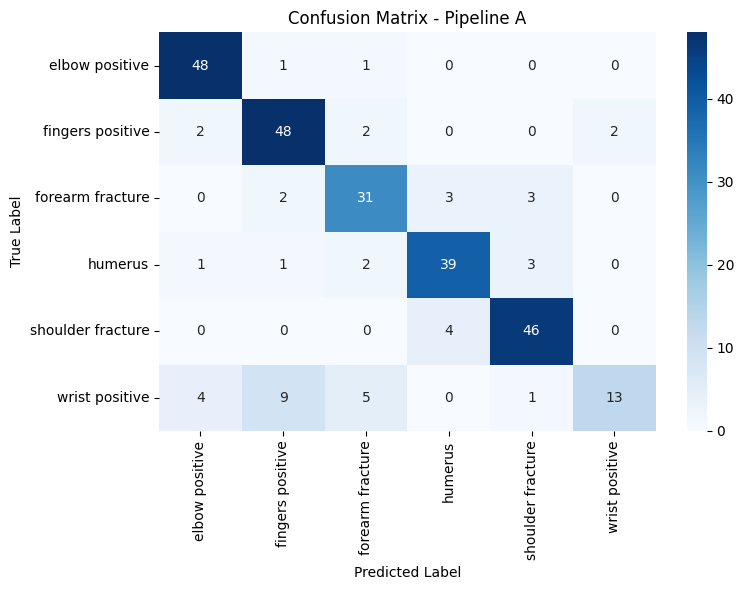

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels_exist_A = np.unique(y_test_A)

cm_A = confusion_matrix(
    y_test_A,
    y_pred_A,
    labels=labels_exist_A
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_A,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[class_names[i] for i in labels_exist_A],
    yticklabels=[class_names[i] for i in labels_exist_A]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Pipeline A")

plt.tight_layout()
plt.show()

## Skenario B

**SKENARIO B1**



Resize

In [ ]:
def resize_image(img, size=224):
    h, w = img.shape[:2]

    # Hitung scale berdasarkan sisi terpanjang
    scale = size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Resize proporsional dulu
    resized = cv2.resize(img, (new_w, new_h))

    # Buat canvas hitam ukuran size x size
    if len(img.shape) == 3:
        canvas = np.zeros((size, size, img.shape[2]), dtype=resized.dtype)
    else:
        canvas = np.zeros((size, size), dtype=resized.dtype)

    # Tempelkan gambar di tengah canvas (center padding)
    top  = (size - new_h) // 2
    left = (size - new_w) // 2

    canvas[top:top+new_h, left:left+new_w] = resized
    resize = canvas

    return resize

Grayscale

In [ ]:
def convert_grayscale(img):
   gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
   return gray

CLAHE B1

In [ ]:
def apply_clahe_B1(img):
    clahe = cv2.createCLAHE(
        clipLimit=2.0)
    return clahe.apply(img)

Normalize

In [ ]:
def normalize_image(img):
    normalized = img.astype(np.float32) / 255.0
    return normalized

Convert to 3 Channel

In [ ]:
def convert_to_3channel(img):
    img_3ch = np.stack([img] * 3, axis=-1)
    return img_3ch

Pipeline B1

In [ ]:
def CLAHE_Pipeline_B1(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")
    resized = resize_image(img)
    gray = convert_grayscale(resized)
    clahe_img = apply_clahe_B1(gray)
    normalized = normalize_image(clahe_img)
    final_img = convert_to_3channel(normalized)
    return final_img

Train Data

In [ ]:
X_train_B1 = []
y_train_B1 = []
for _, row in train_df.iterrows():
    img = CLAHE_Pipeline_B1(row["image_path"])
    if img is not None:
        X_train_B1.append(img)
        y_train_B1.append(row["label"])
X_train_B1 = np.array(X_train_B1, dtype=np.float32)
y_train_B1 = np.array(y_train_B1, dtype=np.int32)
print(X_train_B1.shape)
print(y_train_B1.shape)

(1262, 224, 224, 3)
(1262,)


Validasi Data

In [ ]:
X_val_B1 = []
y_val_B1 = []
for _, row in val_df.iterrows():
    img = CLAHE_Pipeline_B1(row["image_path"])
    if img is not None:
        X_val_B1.append(img)
        y_val_B1.append(row["label"])
X_val_B1 = np.array(X_val_B1, dtype=np.float32)
y_val_B1 = np.array(y_val_B1, dtype=np.int32)
print(X_val_B1.shape)
print(y_val_B1.shape)

(271, 224, 224, 3)
(271,)


Test Data

In [ ]:
X_test_B1 = []
y_test_B1 = []
for _, row in test_df.iterrows():
    img = CLAHE_Pipeline_B1(row["image_path"])
    if img is not None:
        X_test_B1.append(img)
        y_test_B1.append(row["label"])
X_test_B1 = np.array(X_test_B1, dtype=np.float32)
y_test_B1 = np.array(y_test_B1, dtype=np.int32)
print(X_test_B1.shape)
print(y_test_B1.shape)

(271, 224, 224, 3)
(271,)


Augmentasi

In [ ]:
train_datagen_B1 = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True)

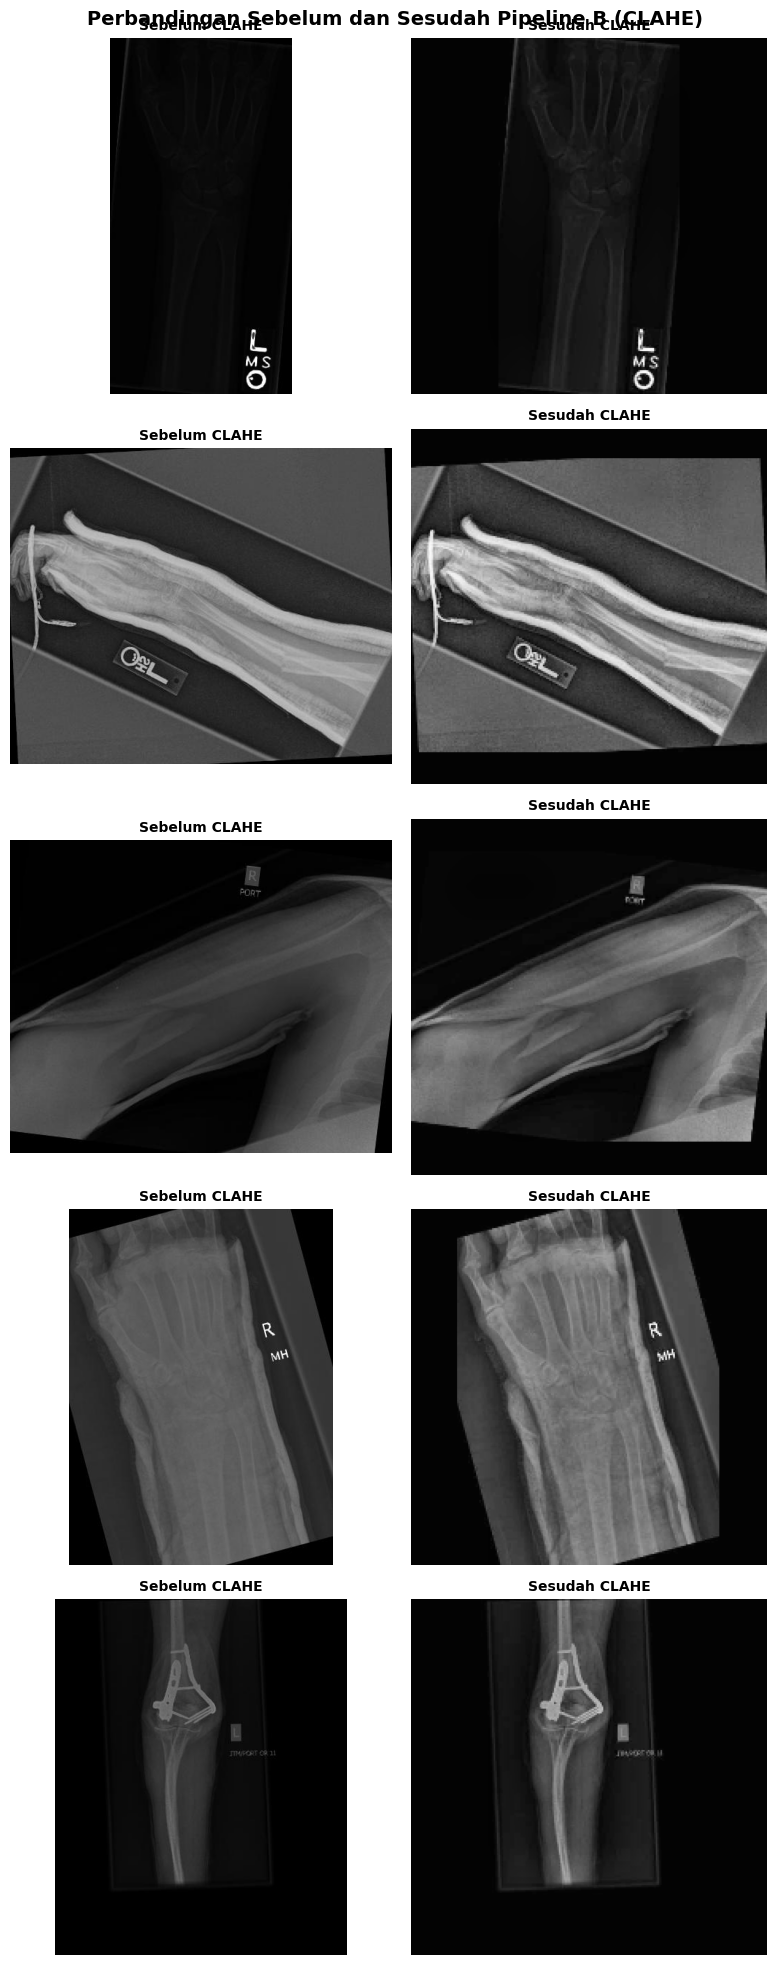

In [ ]:
n_tampil = 5

fig, axes = plt.subplots(n_tampil, 2, figsize=(8, 4 * n_tampil))
for i in range(n_tampil):
    img_path = train_df.iloc[i]["image_path"]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )
    processed = CLAHE_Pipeline_B1(img_path)
    processed_show = (processed * 255).astype(np.uint8)
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(
        "Sebelum CLAHE",
        fontsize=10,
        fontweight='bold'
    )
    axes[i, 0].axis("off")
    axes[i, 1].imshow(processed_show)
    axes[i, 1].set_title(
        "Sesudah CLAHE",
        fontsize=10,
        fontweight='bold'
    )
    axes[i, 1].axis("off")
plt.suptitle(
    "Perbandingan Sebelum dan Sesudah Pipeline B (CLAHE)",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()

plt.show()

**Model B1**

Base model

In [ ]:
num_classes = len(class_names)
base_model_B1 = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet")
base_model_B1.trainable = False

Build model

In [ ]:
model_B1 = models.Sequential([
    base_model_B1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")])

Compile

In [ ]:
model_B1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])


Training

In [ ]:
history_B1 = model_B1.fit(
    train_datagen_B1.flow(
        X_train_B1,
        y_train_B1,
        batch_size=32),
    validation_data=(X_val_B1, y_val_B1),
    epochs=10)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.5618 - loss: 1.2058 - val_accuracy: 0.7712 - val_loss: 0.6635
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.7393 - loss: 0.7092 - val_accuracy: 0.8376 - val_loss: 0.5383
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.7979 - loss: 0.5954 - val_accuracy: 0.8524 - val_loss: 0.4744
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.8241 - loss: 0.4987 - val_accuracy: 0.8376 - val_loss: 0.4582
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8431 - loss: 0.4391 - val_accuracy: 0.8745 - val_loss: 0.3930
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.8700 - loss: 0.3636 - val_accuracy: 0.8819 - val_loss: 0.3311
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8621 - loss: 0.3640 - val_accuracy: 0.9225 - val_loss: 0.2990
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.8867 - loss: 0.3165 - val_accuracy: 0.8967 - val_l

Evaluasi B1

In [ ]:
test_loss_B1, test_acc_B1 = model_B1.evaluate(
    X_test_B1,
    y_test_B1)
print("Test Accuracy :", test_acc_B1)
print("Test Loss :", test_loss_B1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8672 - loss: 0.3412
Test Accuracy : 0.8671586513519287
Test Loss : 0.3412451446056366


Prediksi B1

In [ ]:
y_pred_prob_B1 = model_B1.predict(X_test_B1)
y_pred_B1 = np.argmax(y_pred_prob_B1, axis=1)
print(y_pred_B1[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
[1 5 5 1 1 6 0 4 1 1]


Clasification Report

In [ ]:
y_pred_prob_B1 = model_B1.predict(X_test_B1)
y_pred_B1 = np.argmax(y_pred_prob_B1, axis=1)

print(classification_report(
    y_test_B1,
    y_pred_B1,
    labels=np.unique(y_test_B1),
    target_names=[
        class_names[i]
        for i in np.unique(y_test_B1)]))

9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
                   precision    recall  f1-score   support

   elbow positive       0.94      1.00      0.97        50
 fingers positive       0.76      0.96      0.85        54
 forearm fracture       0.89      0.62      0.73        39
          humerus       0.93      0.83      0.87        46
shoulder fracture       0.85      1.00      0.92        50
   wrist positive       0.91      0.66      0.76        32

         accuracy                           0.87       271
        macro avg       0.88      0.84      0.85       271
     weighted avg       0.88      0.87      0.86       271



Classification Matrix

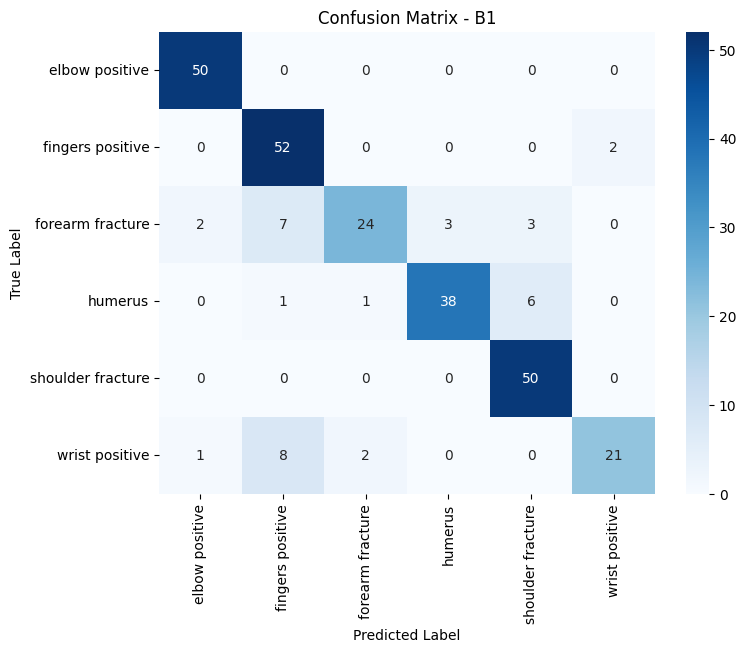

In [ ]:
labels_exist_B1 = np.unique(y_test_B1)
cm_B1 = confusion_matrix(
    y_test_B1,
    y_pred_B1,
    labels=labels_exist_B1)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_B1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        class_names[i]
        for i in labels_exist_B1],
    yticklabels=[
        class_names[i]
        for i in labels_exist_B1])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - B1")
plt.show()

**SKENARIO B2**

In [ ]:
def apply_clahe_B2(img):
    clahe = cv2.createCLAHE(
        tileGridSize=(2,2))
    return clahe.apply(img)

Pipeline B2

In [ ]:
def CLAHE_Pipeline_B2(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")
    resized = resize_image(img)
    gray = convert_grayscale(resized)
    clahe_img = apply_clahe_B2(gray)
    normalized = normalize_image(clahe_img)
    final_img = convert_to_3channel(normalized)
    return final_img

Train Data B2

In [ ]:
X_train_B2 = []
y_train_B2 = []
for _, row in train_df.iterrows():
    img = CLAHE_Pipeline_B2(row["image_path"])
    if img is not None:
        X_train_B2.append(img)
        y_train_B2.append(row["label"])
X_train_B2 = np.array(X_train_B2, dtype=np.float32)
y_train_B2 = np.array(y_train_B2, dtype=np.int32)

Validation Data B2

In [ ]:
X_val_B2 = []
y_val_B2 = []
for _, row in val_df.iterrows():
    img = CLAHE_Pipeline_B2(row["image_path"])
    if img is not None:
        X_val_B2.append(img)
        y_val_B2.append(row["label"])
X_val_B2 = np.array(X_val_B2, dtype=np.float32)
y_val_B2 = np.array(y_val_B2, dtype=np.int32)

Test Data B2

In [ ]:
X_test_B2 = []
y_test_B2 = []
for _, row in test_df.iterrows():
    img = CLAHE_Pipeline_B2(row["image_path"])
    if img is not None:
        X_test_B2.append(img)
        y_test_B2.append(row["label"])
X_test_B2 = np.array(X_test_B2, dtype=np.float32)
y_test_B2 = np.array(y_test_B2, dtype=np.int32)

Augmentasi

In [ ]:
train_datagen_B2 = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True)

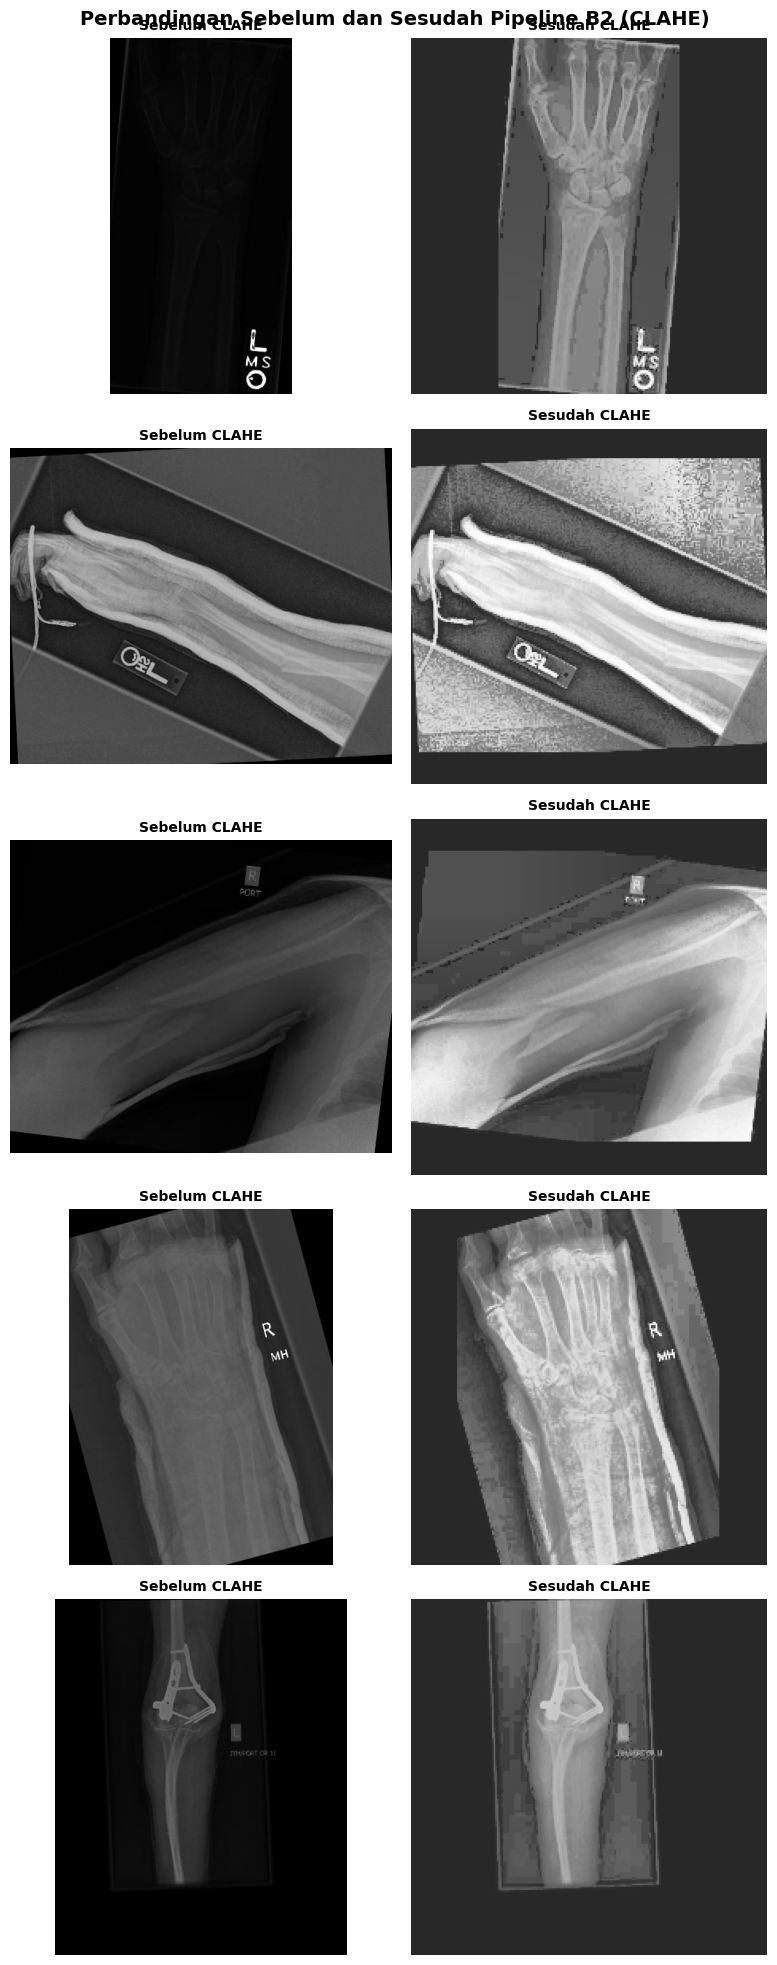

In [ ]:
n_tampil = 5

fig, axes = plt.subplots(n_tampil, 2, figsize=(8, 4 * n_tampil))
for i in range(n_tampil):
    img_path = train_df.iloc[i]["image_path"]
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )
    processed = CLAHE_Pipeline_B2(img_path)
    processed_show = (processed * 255).astype(np.uint8)
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(
        "Sebelum CLAHE",
        fontsize=10,
        fontweight='bold'
    )
    axes[i, 0].axis("off")
    axes[i, 1].imshow(processed_show)
    axes[i, 1].set_title(
        "Sesudah CLAHE",
        fontsize=10,
        fontweight='bold'
    )
    axes[i, 1].axis("off")
plt.suptitle(
    "Perbandingan Sebelum dan Sesudah Pipeline B2 (CLAHE)",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()

plt.show()

Model B2

In [ ]:
base_model_B2 = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet")
base_model_B2.trainable = False

Build Model B2

In [ ]:
model_B2 = models.Sequential([
    base_model_B2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

Compile Model B2

In [ ]:
model_B2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Training B2

In [ ]:
model_B2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_B2 = model_B2.fit(
    train_datagen_B1.flow(
        X_train_B2,
        y_train_B2,
        batch_size=32
    ),
    validation_data=(X_val_B2, y_val_B2),
    epochs=10)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.5325 - loss: 1.2539 - val_accuracy: 0.7528 - val_loss: 0.7446
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7448 - loss: 0.7573 - val_accuracy: 0.7970 - val_loss: 0.6092
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7750 - loss: 0.6277 - val_accuracy: 0.8303 - val_loss: 0.5075
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.8082 - loss: 0.5489 - val_accuracy: 0.8524 - val_loss: 0.4967
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.8288 - loss: 0.4832 - val_accuracy: 0.8598 - val_loss: 0.4512
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8360 - loss: 0.4493 - val_accuracy: 0.8229 - val_loss: 0.5027
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8431 - loss: 0.4156 - val_accuracy: 0.8487 - val_loss: 0.3954
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8471 - loss: 0.4121 - val_accuracy: 0.8598 - val_loss:

Evaluasi B2

In [ ]:
test_loss_B2, test_acc_B2 = model_B2.evaluate(
    X_test_B2,
    y_test_B2)
print("Test Accuracy :", test_acc_B2)
print("Test Loss :", test_loss_B2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8376 - loss: 0.3958
Test Accuracy : 0.8376383781433105
Test Loss : 0.39577773213386536


Classification Report B2

In [ ]:
y_pred_prob_B2 = model_B2.predict(X_test_B2)
y_pred_B2 = np.argmax(y_pred_prob_B2, axis=1)

print(classification_report(
    y_test_B2,
    y_pred_B2,
    labels=np.unique(y_test_B2),
    target_names=[
        class_names[i]
        for i in np.unique(y_test_B2)]))

9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
                   precision    recall  f1-score   support

   elbow positive       0.85      1.00      0.92        50
 fingers positive       0.75      0.85      0.80        54
 forearm fracture       0.84      0.82      0.83        39
          humerus       0.88      0.91      0.89        46
shoulder fracture       0.92      0.90      0.91        50
   wrist positive       0.75      0.38      0.50        32

         accuracy                           0.84       271
        macro avg       0.83      0.81      0.81       271
     weighted avg       0.83      0.84      0.83       271



Confusion Matrix

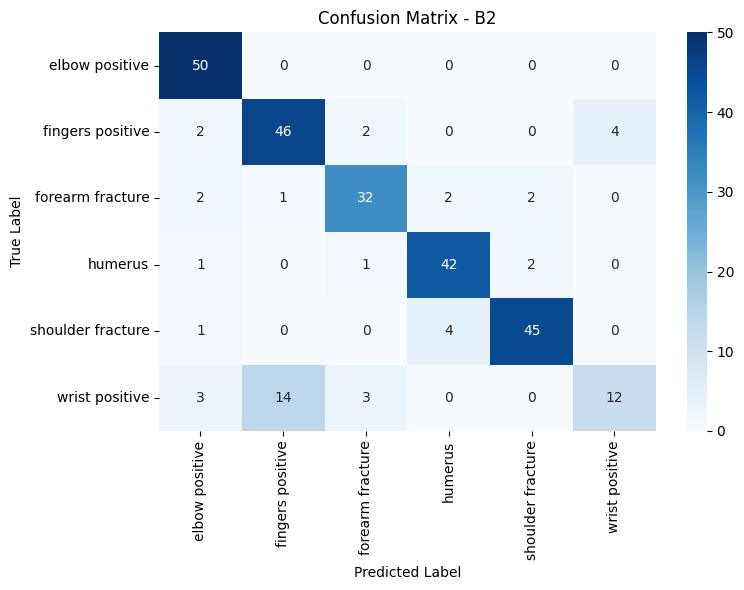

In [ ]:
labels_exist_B2 = np.unique(y_test_B2)
cm_B2 = confusion_matrix(
    y_test_B2,
    y_pred_B2,
    labels=labels_exist_B2)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_B2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        class_names[i]
        for i in labels_exist_B2
    ],
    yticklabels=[
        class_names[i]
        for i in labels_exist_B2])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - B2")
plt.tight_layout()
plt.show()

Perbandingan Hasil

In [ ]:
comparison = pd.DataFrame({
    "Skenario": [
        "clipLimit",
        "tileGridSize"],

    "Accuracy": [
        test_acc_B1,
        test_acc_B2],

    "Loss": [
        test_loss_B1,
        test_loss_B2]})

comparison

,Skenario,Accuracy,Loss
0,clipLimit,0.867159,0.341245
1,tileGridSize,0.837638,0.395778


Visualisasi Accuracy

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
accuracy = [test_acc_B1,test_acc_B2]

labels = [
    'B1\n(clipLimit=2.0)',
    'B2\n(tileGridSize=(2,2))']

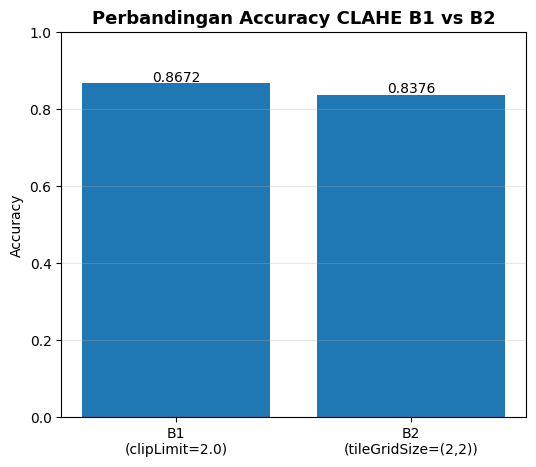

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(labels, accuracy)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.4f}',
        ha='center',
        fontsize=10)
plt.title(
    'Perbandingan Accuracy CLAHE B1 vs B2',
    fontsize=13,
    fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

Visualisasi Loss

In [ ]:
loss = [test_loss_B1, test_loss_B2]
labels = [
    'B1\n(clipLimit=2.0)',
    'B2\n(tileGridSize=(2,2))']

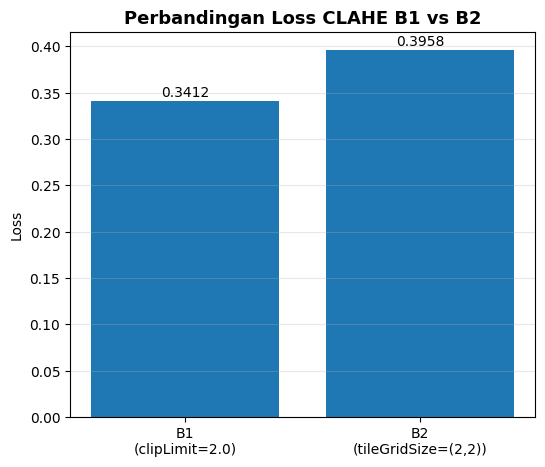

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(labels, loss)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.4f}',
        ha='center',
        fontsize=10)

plt.title(
    'Perbandingan Loss CLAHE B1 vs B2',
    fontsize=13,
    fontweight='bold')
plt.ylabel('Loss')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Skenario C

In [ ]:
def resize_image(img, size=224):

    h, w = img.shape[:2]

    scale = size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h))

    if len(img.shape) == 3:
        canvas = np.zeros((size, size, img.shape[2]), dtype=resized.dtype)
    else:
        canvas = np.zeros((size, size), dtype=resized.dtype)

    top  = (size - new_h) // 2
    left = (size - new_w) // 2

    canvas[top:top+new_h, left:left+new_w] = resized

    return canvas

In [ ]:
def convert_grayscale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

In [ ]:
def apply_adaptive_mean(img):

    adaptive = cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )
    return adaptive

In [ ]:
def normalize_image(img):
    normalized = img.astype(np.float32) / 255.0
    return normalized

In [ ]:
def convert_to_3channel(img):
    final_img = np.stack([img] * 3, axis=-1)
    return final_img

In [ ]:
def Adaptive_Mean_Pipeline(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")
    resized = resize_image(img)
    gray = convert_grayscale(resized)
    adaptive_img = apply_adaptive_mean(gray)
    normalized = normalize_image(adaptive_img)
    final_img = convert_to_3channel(normalized)

    return final_img

In [ ]:
X_train_C1 = []
y_train_C1 = []
for _, row in train_df.iterrows():
    img = Adaptive_Mean_Pipeline(row["image_path"])
    if img is not None:
        X_train_C1.append(img)
        y_train_C1.append(row["label"])
X_train_C1 = np.array(X_train_C1, dtype=np.float32)
y_train_C1 = np.array(y_train_C1, dtype=np.int32)

print(X_train_C1.shape)
print(y_train_C1.shape)

(1262, 224, 224, 3)
(1262,)


In [ ]:
X_val_C1 = []
y_val_C1 = []
for _, row in val_df.iterrows():
    img = Adaptive_Mean_Pipeline(row["image_path"])
    if img is not None:
        X_val_C1.append(img)
        y_val_C1.append(row["label"])
X_val_C1 = np.array(X_val_C1, dtype=np.float32)
y_val_C1 = np.array(y_val_C1, dtype=np.int32)

print(X_val_C1.shape)
print(y_val_C1.shape)

(271, 224, 224, 3)
(271,)


In [ ]:
X_test_C1 = []
y_test_C1 = []
for _, row in test_df.iterrows():
    img = Adaptive_Mean_Pipeline(row["image_path"])
    if img is not None:
        X_test_C1.append(img)
        y_test_C1.append(row["label"])
X_test_C1 = np.array(X_test_C1, dtype=np.float32)
y_test_C1 = np.array(y_test_C1, dtype=np.int32)

print(X_test_C1.shape)
print(y_test_C1.shape)

(271, 224, 224, 3)
(271,)


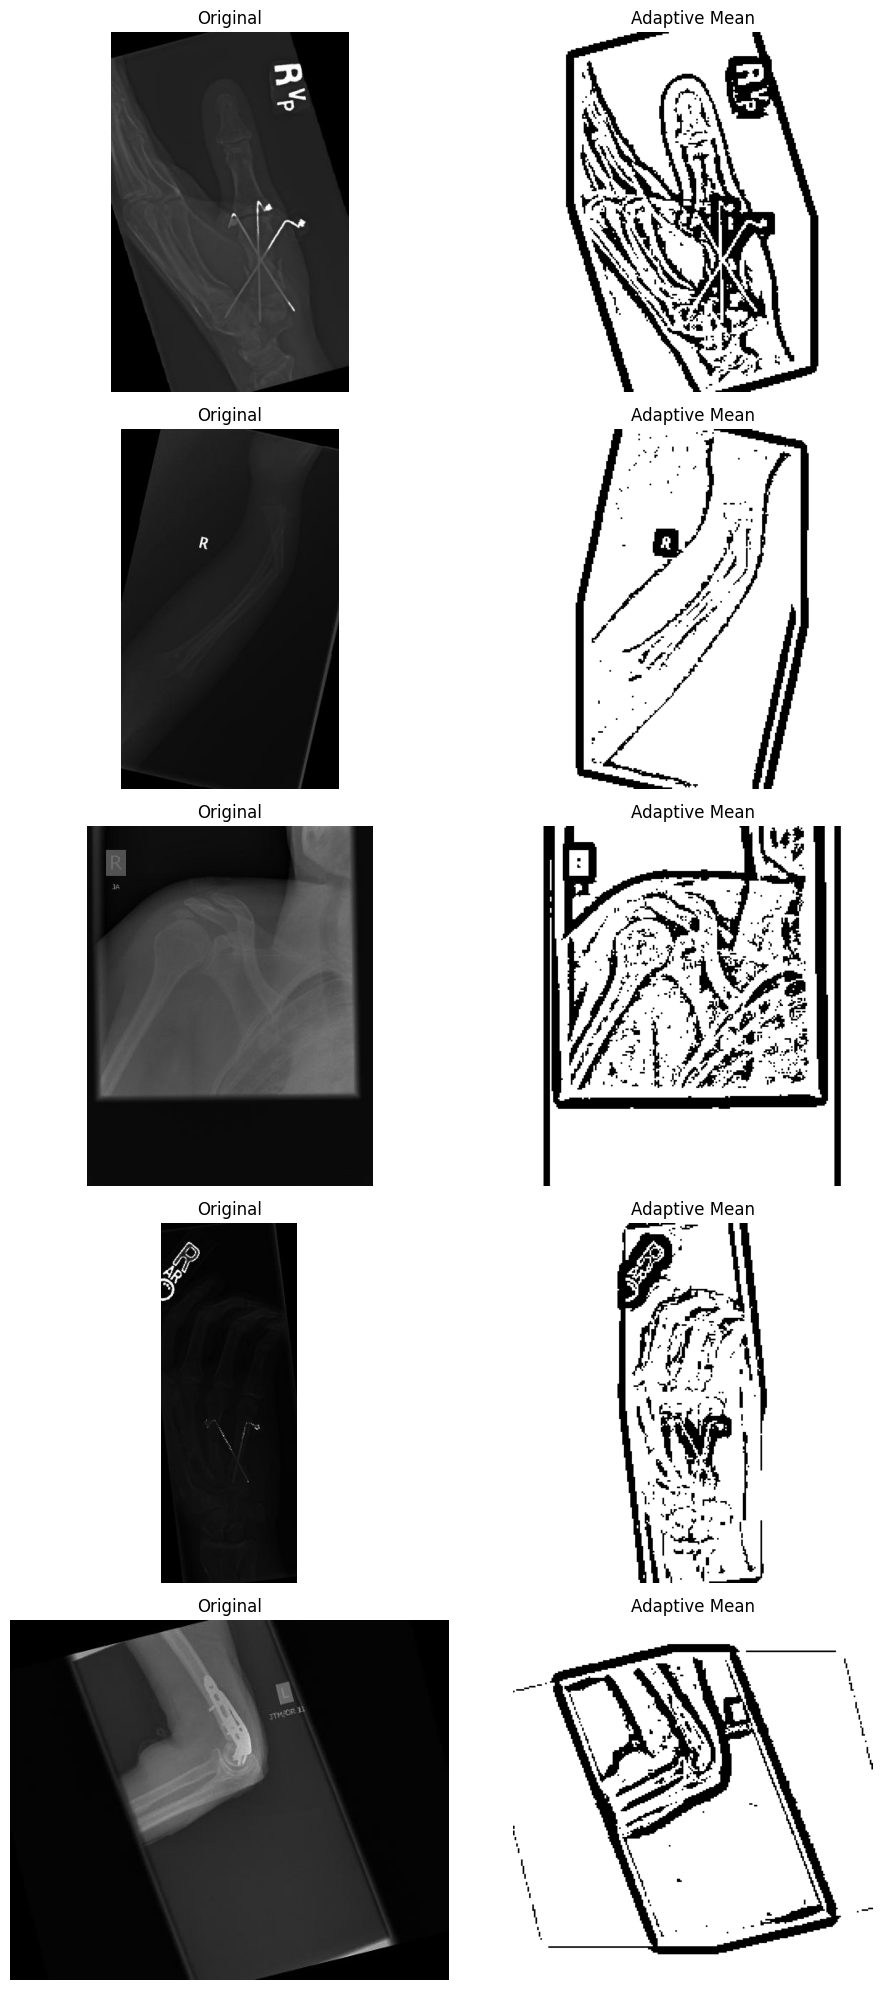

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(10,20))
sample_df = train_df.sample(5)
for i, (_, row) in enumerate(sample_df.iterrows()):
    original = cv2.imread(row["image_path"])
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    processed = Adaptive_Mean_Pipeline(row["image_path"])
    axes[i,0].imshow(original)
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")
    axes[i,1].imshow(processed[:,:,0], cmap='gray')
    axes[i,1].set_title("Adaptive Mean")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_datagen_C1 = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True)

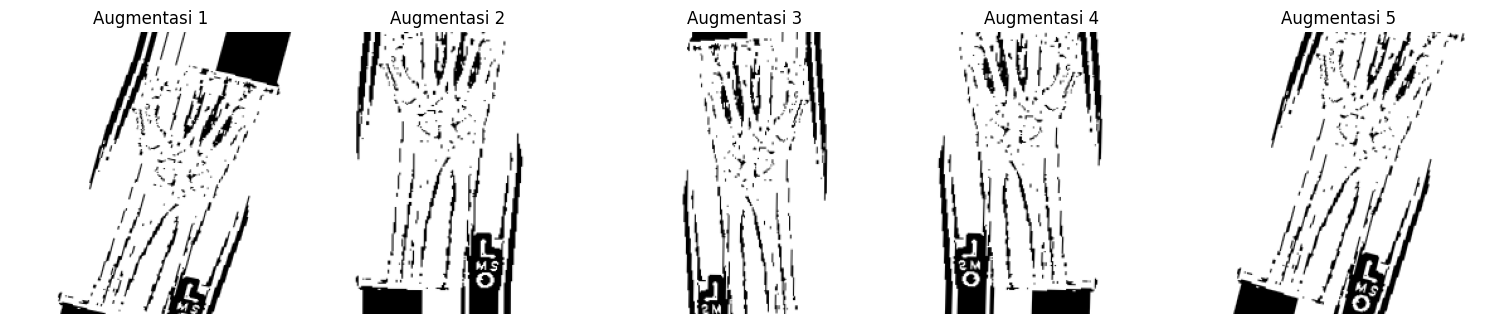

In [ ]:
sample_img = X_train_C1[0]
sample_img = np.expand_dims(sample_img, axis=0)
augment_iter = train_datagen_C1.flow(
    sample_img,
    batch_size=1
)
fig, axes = plt.subplots(1, 5, figsize=(15,5))
for i in range(5):
    augmented_img = next(augment_iter)[0]
    axes[i].imshow(augmented_img)
    axes[i].set_title(f"Augmentasi {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Model C1

In [ ]:
base_model_C1 = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model_C1.trainable = False

In [ ]:
model_C1 = models.Sequential([
    base_model_C1,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")])
model_C1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

compile

In [ ]:
model_C1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_C1 = model_C1.fit(
    train_datagen_C1.flow(
        X_train_C1,
        y_train_C1,
        batch_size=32),
    validation_data=(X_val_C1, y_val_C1),
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.4651 - loss: 1.4218 - val_accuracy: 0.6199 - val_loss: 0.9907
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6410 - loss: 0.9710 - val_accuracy: 0.6347 - val_loss: 0.9298
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7290 - loss: 0.7860 - val_accuracy: 0.6900 - val_loss: 0.7873
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7282 - loss: 0.7481 - val_accuracy: 0.6568 - val_loss: 0.8236
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7409 - loss: 0.6936 - val_accuracy: 0.7122 - val_loss: 0.7226
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7781 - loss: 0.6083 - val_accuracy: 0.6753 - val_loss: 0.7845
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7686 - loss: 0.6047 - val_accuracy: 0.7306 - val_loss: 0.7377
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.7868 - loss: 0.5899 - val_accuracy: 0.7159 - val_loss:

In [ ]:
test_loss_C1, test_acc_C1 = model_C1.evaluate(
    X_test_C1,
    y_test_C1)

print("Test Accuracy :", test_acc_C1)
print("Test Loss :", test_loss_C1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8155 - loss: 0.5438
Test Accuracy : 0.8154981732368469
Test Loss : 0.5437607169151306


In [ ]:
y_pred_prob_C1 = model_C1.predict(X_test_C1)
y_pred_C1 = np.argmax(
    y_pred_prob_C1,
    axis=1
)
print(y_pred_C1[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step
[1 5 5 1 6 6 2 4 1 4]


In [ ]:
y_pred_prob_C1 = model_C1.predict(X_test_C1)
y_pred_C1 = np.argmax(y_pred_prob_C1, axis=1)

print(classification_report(
    y_test_C1,
    y_pred_C1,
    labels=np.unique(y_test_C1),
    target_names=[
        class_names[i]
        for i in np.unique(y_test_C1)]))

9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
                   precision    recall  f1-score   support

   elbow positive       0.95      0.78      0.86        50
 fingers positive       0.77      0.80      0.78        54
 forearm fracture       0.63      0.87      0.73        39
          humerus       0.93      0.83      0.87        46
shoulder fracture       0.91      0.96      0.93        50
   wrist positive       0.73      0.59      0.66        32

         accuracy                           0.82       271
        macro avg       0.82      0.80      0.81       271
     weighted avg       0.83      0.82      0.82       271



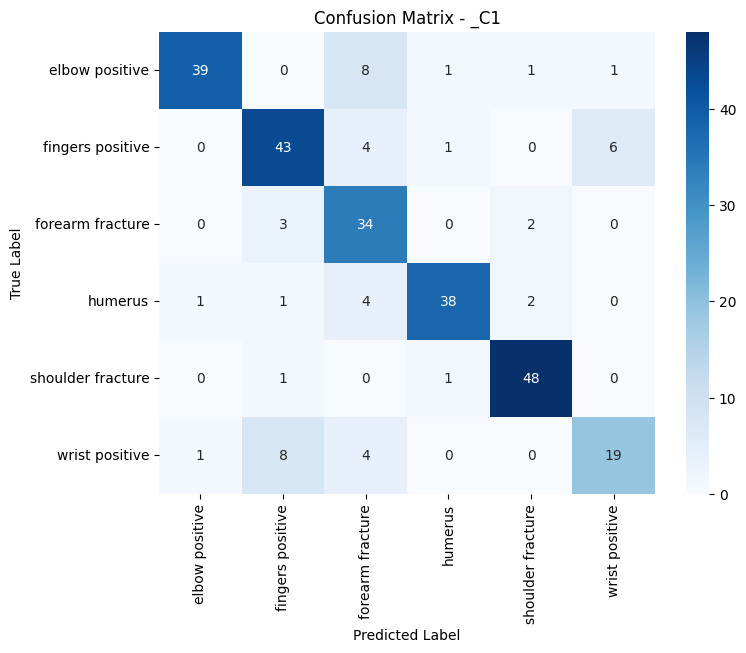

In [ ]:
labels_exist_C1 = np.unique(y_test_C1)
cm_C1 = confusion_matrix(
    y_test_C1,
    y_pred_C1,
    labels=labels_exist_C1)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_C1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        class_names[i]
        for i in labels_exist_C1],
    yticklabels=[
        class_names[i]
        for i in labels_exist_C1])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - _C1")
plt.show()

**Skenario C2**

In [ ]:
def apply_adaptive_gaussian(img):

    adaptive = cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    return adaptive

Pipeline C2

In [ ]:
def Adaptive_Gaussian_Pipeline(img_path):

    img = cv2.imread(str(img_path))

    if img is None:
        raise ValueError(f"Gagal membaca gambar: {img_path}")

    resized = resize_image(img)
    gray = convert_grayscale(resized)
    adaptive_img = apply_adaptive_gaussian(gray)
    normalized = normalize_image(adaptive_img)
    final_img = convert_to_3channel(normalized)
    return final_img

Train Data C2

In [ ]:
X_train_C2 = []
y_train_C2 = []

for _, row in train_df.iterrows():
    img = Adaptive_Gaussian_Pipeline(row["image_path"])
    if img is not None:

        X_train_C2.append(img)
        y_train_C2.append(row["label"])

X_train_C2 = np.array(X_train_C2, dtype=np.float32)
y_train_C2 = np.array(y_train_C2, dtype=np.int32)

print(X_train_C2.shape)
print(y_train_C2.shape)

(1262, 224, 224, 3)
(1262,)


Validation Data C2

In [ ]:
X_val_C2 = []
y_val_C2 = []

for _, row in val_df.iterrows():

    img = Adaptive_Gaussian_Pipeline(row["image_path"])

    if img is not None:

        X_val_C2.append(img)
        y_val_C2.append(row["label"])

X_val_C2 = np.array(X_val_C2, dtype=np.float32)
y_val_C2 = np.array(y_val_C2, dtype=np.int32)

print(X_val_C2.shape)
print(y_val_C2.shape)

(271, 224, 224, 3)
(271,)


Test Data C2

In [ ]:
X_test_C2 = []
y_test_C2 = []

for _, row in test_df.iterrows():

    img = Adaptive_Gaussian_Pipeline(row["image_path"])

    if img is not None:

        X_test_C2.append(img)
        y_test_C2.append(row["label"])

X_test_C2 = np.array(X_test_C2, dtype=np.float32)
y_test_C2 = np.array(y_test_C2, dtype=np.int32)

print(X_test_C2.shape)
print(y_test_C2.shape)

(271, 224, 224, 3)
(271,)


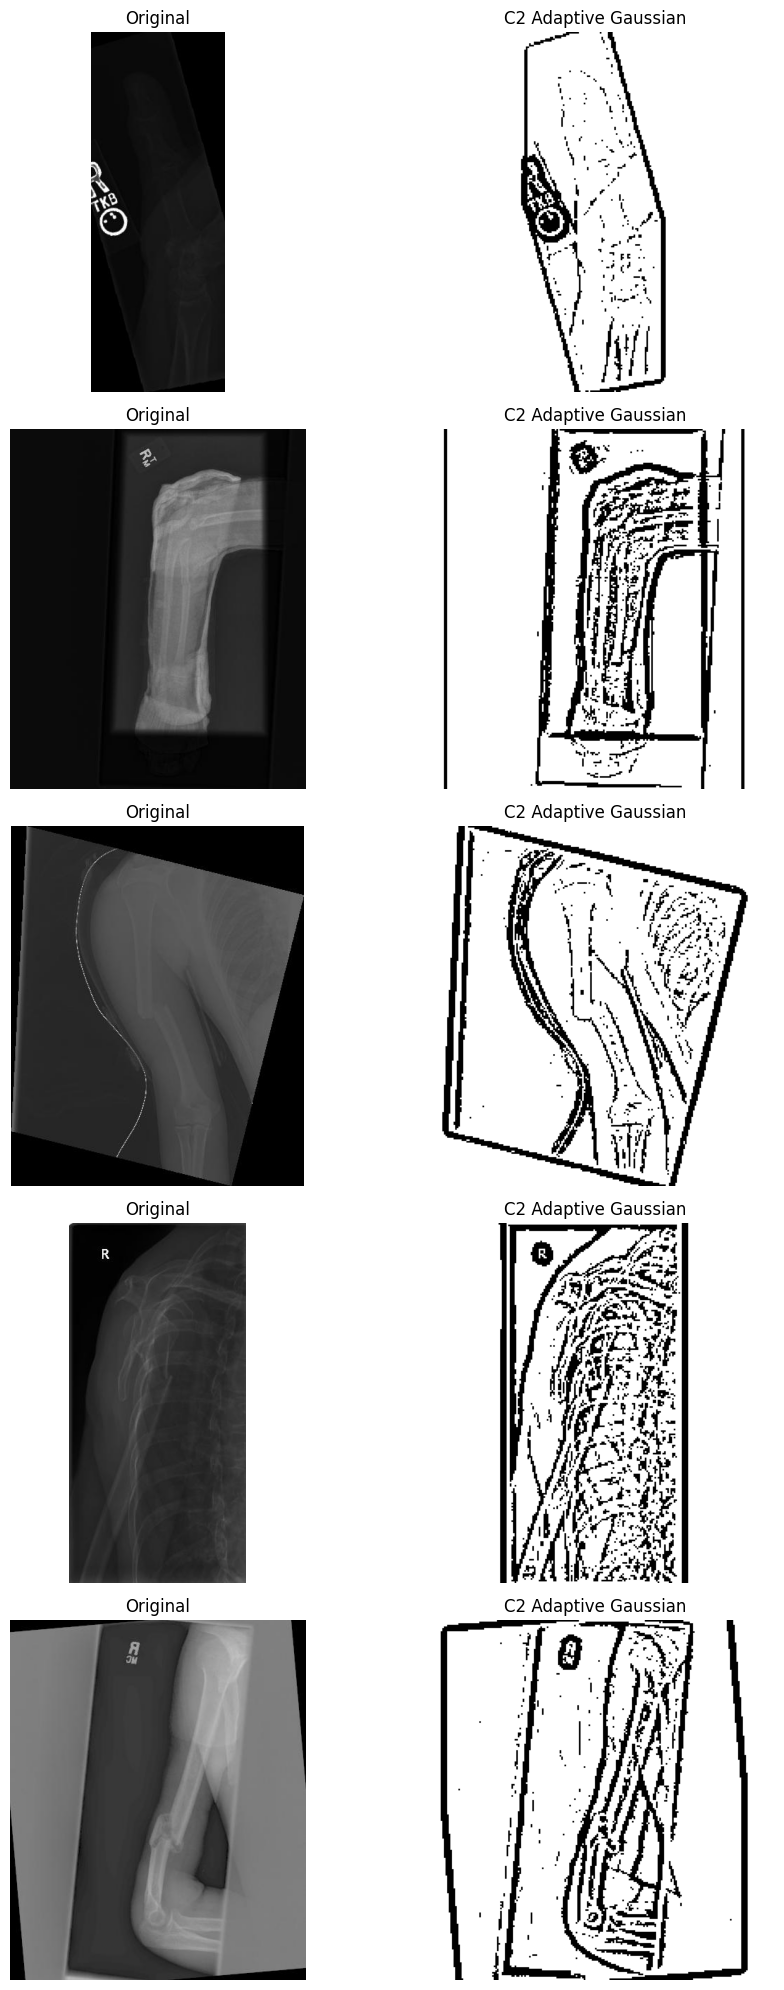

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(10,20))

sample = train_df.sample(5)

for i, (_, row) in enumerate(sample.iterrows()):

    orig = cv2.imread(row["image_path"])
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    proc = Adaptive_Gaussian_Pipeline(row["image_path"])

    axes[i,0].imshow(orig)
    axes[i,0].set_title("Original")
    axes[i,0].axis("off")

    axes[i,1].imshow(proc[:,:,0], cmap="gray")
    axes[i,1].set_title("C2 Adaptive Gaussian")
    axes[i,1].axis("off")

plt.tight_layout()
plt.show()

Augmentasi

In [ ]:
train_datagen_C2 = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True)

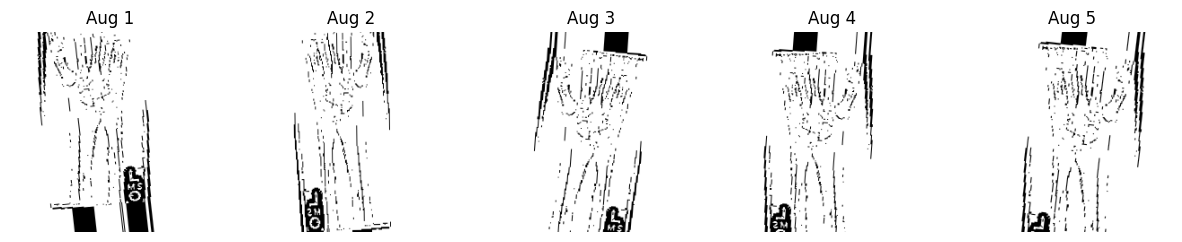

In [ ]:
img = X_train_C2[0]
img = np.expand_dims(img, axis=0)

gen = train_datagen_C2.flow(img, batch_size=1)

fig, ax = plt.subplots(1,5, figsize=(15,5))

for i in range(5):
    ax[i].imshow(next(gen)[0])
    ax[i].axis("off")
    ax[i].set_title(f"Aug {i+1}")

plt.show()

**Model C2**

Base Model

In [ ]:
num_classes = len(class_names)
base_model_C2 = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model_C2.trainable = False

Build Model

In [ ]:
model_C2 = models.Sequential([
    base_model_C2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(
        num_classes,
        activation="softmax")])
model_C2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Compile

In [ ]:
model_C2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

Training

In [ ]:
history_C2 = model_C2.fit(
    train_datagen_C2.flow(
        X_train_C2,
        y_train_C2,
        batch_size=32),
    validation_data=(X_val_C2, y_val_C2),
    epochs=10)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.4786 - loss: 1.4093 - val_accuracy: 0.6199 - val_loss: 1.0051
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6585 - loss: 0.9197 - val_accuracy: 0.6162 - val_loss: 0.9833
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.6941 - loss: 0.8270 - val_accuracy: 0.6937 - val_loss: 0.8066
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7219 - loss: 0.7480 - val_accuracy: 0.6974 - val_loss: 0.8161
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7536 - loss: 0.6817 - val_accuracy: 0.6605 - val_loss: 0.8773
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7591 - loss: 0.6452 - val_accuracy: 0.7380 - val_loss: 0.7186
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7512 - loss: 0.6385 - val_accuracy: 0.7306 - val_loss: 0.7677
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8011 - loss: 0.5346 - val_accuracy: 0.7380 - val_loss:

In [ ]:
test_loss_C2, test_acc_C2 = model_C2.evaluate(
    X_test_C2,
    y_test_C2)

print("Test Accuracy :", test_acc_C2)
print("Test Loss :", test_loss_C2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7897 - loss: 0.5843
Test Accuracy : 0.7896679043769836
Test Loss : 0.5842835903167725


In [ ]:
y_pred_prob_C2 = model_C2.predict(X_test_C2)
y_pred_C2 = np.argmax(
    y_pred_prob_C2,
    axis=1
)
print(y_pred_C2[:10])

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
[1 5 5 1 6 5 2 4 5 4]


In [ ]:
print(classification_report(
    y_test_C2,
    y_pred_C2,
    labels=np.unique(y_test_C2),
    target_names=[
        class_names[i]
        for i in np.unique(y_test_C2)]))

                   precision    recall  f1-score   support

   elbow positive       0.87      0.80      0.83        50
 fingers positive       0.78      0.72      0.75        54
 forearm fracture       0.84      0.79      0.82        39
          humerus       0.82      0.87      0.84        46
shoulder fracture       0.71      0.96      0.81        50
   wrist positive       0.76      0.50      0.60        32

         accuracy                           0.79       271
        macro avg       0.80      0.77      0.78       271
     weighted avg       0.80      0.79      0.78       271



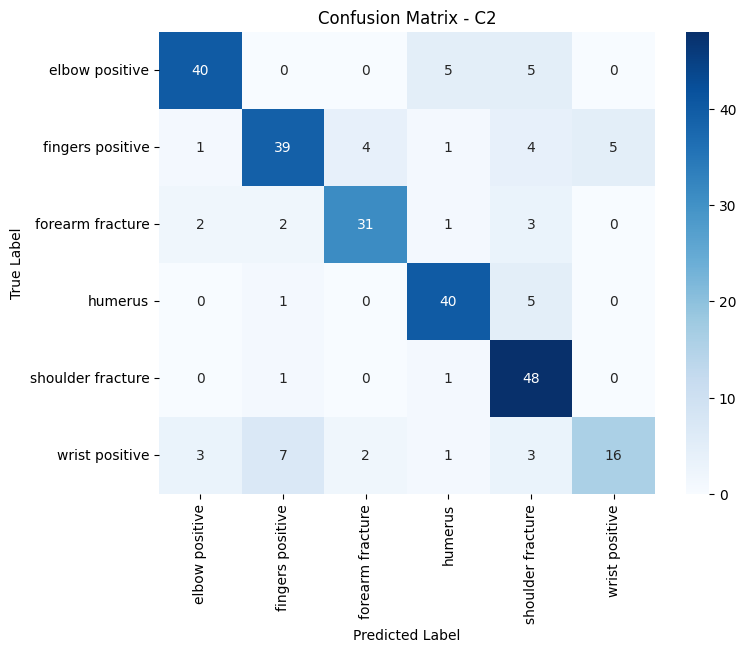

In [ ]:
labels_exist_C2 = np.unique(y_test_C2)
cm_C2 = confusion_matrix(
    y_test_C2,
    y_pred_C2,
    labels=labels_exist_C2)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm_C2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        class_names[i]
        for i in labels_exist_C2],
    yticklabels=[
        class_names[i]
        for i in labels_exist_C2])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - C2")
plt.show()

Visualisasi Accuracy

In [ ]:
accuracy = [test_acc_C1,test_acc_C2]
labels = [
    'C1\n(Adaptive Mean)',
    'C2\n(Adaptive Gaussian)']

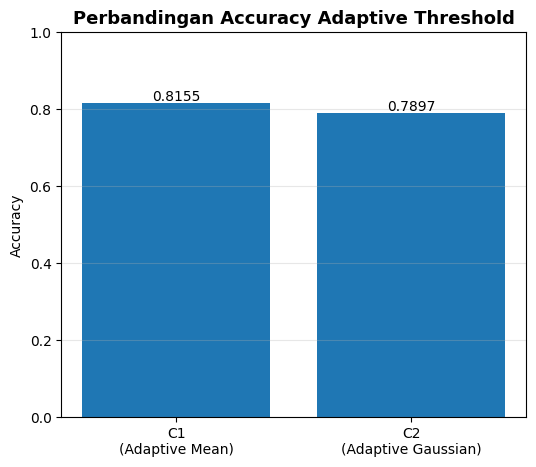

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(labels, accuracy)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.4f}',
        ha='center',
        fontsize=10)
plt.title(
    'Perbandingan Accuracy Adaptive Threshold',
    fontsize=13,
    fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)
plt.show()

Visualisasi Loss

In [ ]:
loss = [test_loss_C1, test_loss_C2]
labels = ['C1\n(Adaptive Mean)', 'C2\n(Adaptive Gaussian)']

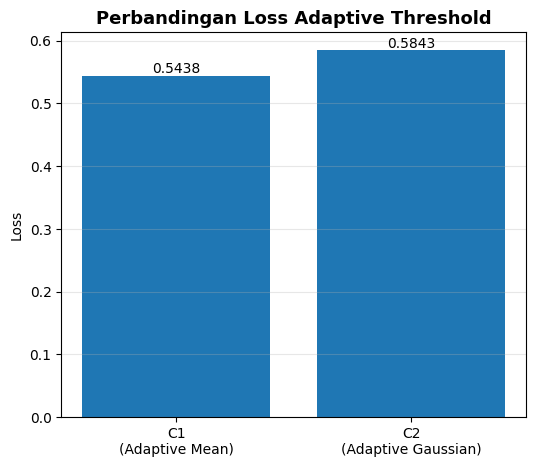

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(labels, loss)
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.4f}',
        ha='center',
        fontsize=10)
plt.title(
    'Perbandingan Loss Adaptive Threshold',
    fontsize=13,
    fontweight='bold')

plt.ylabel('Loss')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Visualisasi perbandingan Accuracy Baseline vs terbaik Pipeline b vs Pipeline C

In [ ]:
labels = [
    "Baseline_A",
    "Pipeline B1",
    "Adaptive Mean"
]

accuracy = [
    test_acc_A,
    test_acc_B1,
    test_acc_C1
]

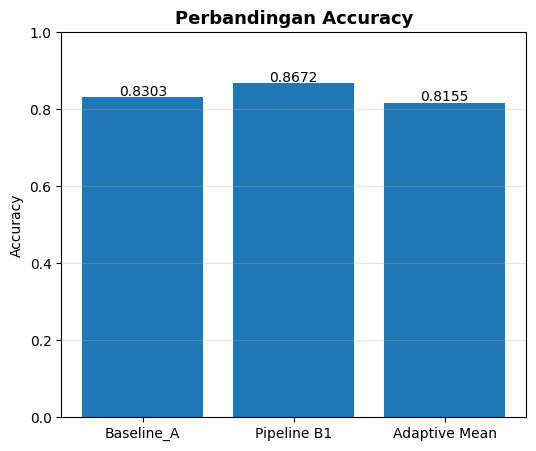

In [ ]:
plt.figure(figsize=(6,5))

bars = plt.bar(labels, accuracy)

for bar, val in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.005,
        f'{val:.4f}',
        ha='center',
        fontsize=10
    )
plt.title(
    'Perbandingan Accuracy',
    fontsize=13,
    fontweight='bold'
)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.show()

# Visualisasi perbandingan Loss Baseline vs terbaik Pipeline b vs Pipeline C

In [ ]:
labels = [
    "Baseline_A",
    "Pipeline B1",
    "Adaptive Mean"
]

loss = [
    test_loss_A,
    test_loss_B1,
    test_loss_C1
]

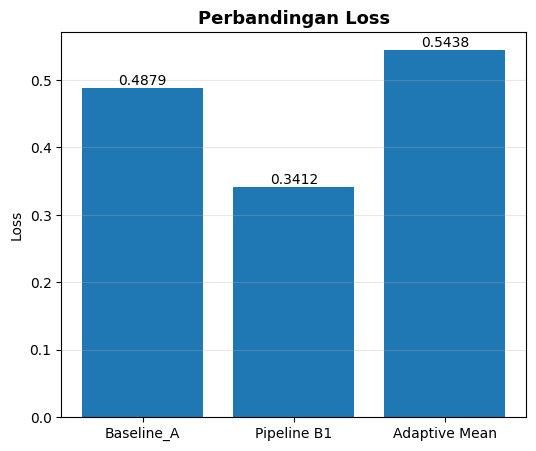

In [ ]:
plt.figure(figsize=(6,5))
bars = plt.bar(labels, loss)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval:.4f}',
        ha='center',
        fontsize=10
    )
plt.title(
    'Perbandingan Loss',
    fontsize=13,
    fontweight='bold'
)
plt.ylabel('Loss')
plt.grid(axis='y', alpha=0.3)
plt.show()